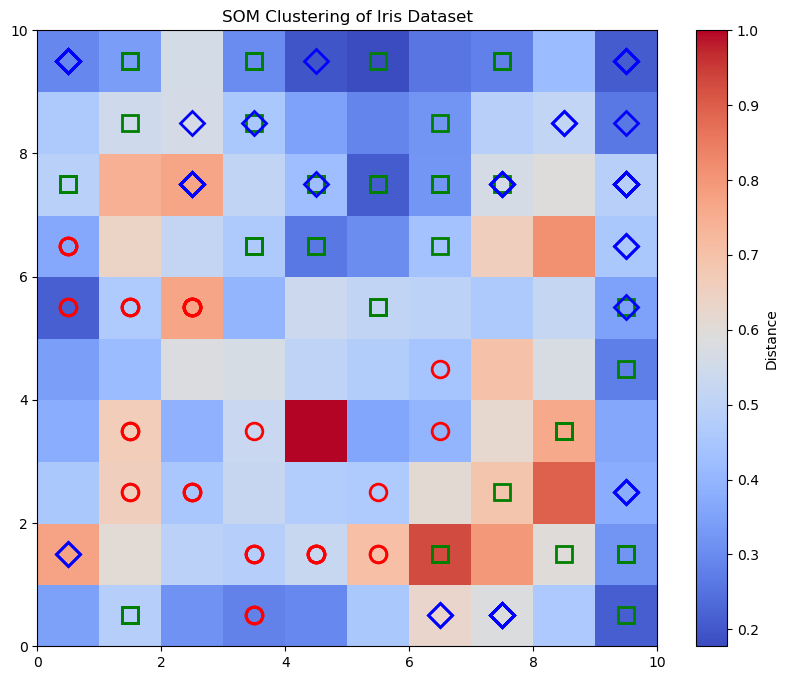

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
import matplotlib.pyplot as plt
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
# Initialize and train SOM
som = MiniSom(x=10, y=10, input_len=X_scaled.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_scaled)
som.train_random(X_scaled, num_iteration=200)
# Plot the SOM Distance Map (U-Matrix)
plt.figure(figsize=(10, 8))
plt.pcolor(som.distance_map().T, cmap='coolwarm') # U-Matrix
plt.colorbar(label='Distance')
# Overlay the iris class labels
markers = ['o', 's', 'D']
colors = ['r', 'g', 'b']
for i, x in enumerate(X_scaled):
    w = som.winner(x)
    plt.plot(w[0] + 0.5,
             w[1] + 0.5,
             markers[y[i]],
             markerfacecolor='None',
             markeredgecolor=colors[y[i]],
             markersize=12,
             markeredgewidth=2)

plt.title("SOM Clustering of Iris Dataset")
plt.show()